In [1]:
# Import von Bibliotheken
from datasets import load_dataset
import urllib.request
import io,re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import os
# Deutsche Stopwörter laden
!pip install nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords = stopwords.words('german')

from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
!pip install sentence-transformers

[nltk_data] Downloading package punkt to /home/haloh001/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/haloh001/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
!pip install "transformers==4.47.1" "sentence-transformers"
from sentence_transformers import SentenceTransformer

In [3]:
!pip install bertopic
!pip uninstall -y umap umap-learn
!pip install umap-learn
from umap import UMAP
import hdbscan
import umap
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

Found existing installation: umap-learn 0.5.12
Uninstalling umap-learn-0.5.12:
  Successfully uninstalled umap-learn-0.5.12
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)


In [4]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

In [5]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
CDU_text = CDU_text[135:]   # da vor der eigentlichen Langfassung im CDU/CSU-Programm noch eine Kurzfassung vorangeht, wird diese ausgeblendet

In [6]:
# für das Wahlprogramm der CDU

for index, i in enumerate(CDU_text):
  if len(i) < 90:
    print(index, i)

6 Wir wollen ein Land, das wieder Wohlstand für alle schafft.
7 Wir wollen ein Land, das frei und wieder sicher ist.
8 Wir wollen ein Land, das wieder zusammenhält.
9 Wir wollen Deutschland wieder nach vorne bringen.
10 Ein Deutschland, auf das wir wieder stolz sein können.
13 Wir wollen ein Land, das wieder Wohlstand für alle schafft.
14 Wir wollen Deutschland wieder nach vorne bringen.
15 Ein Deutschland, auf das wir wieder stolz sein können.
16 Unser Plan:
17 Leistung muss sich wieder lohnen.
18 Arbeitsrecht modernisieren.
19 Arbeits- und Fachkräfte gewinnen.
20 Wir handeln.
41 Unser Plan:
42 Steuerlast verringern.
43 Bürokratie spürbar abbauen.
44 Steuern vereinfachen.
45 Resilienz der Wirtschaft stärken.
46 Freien Handel und Exporte unterstützen.
47 Wir handeln.
96 Unser Plan:
97 Für bezahlbare Energie sorgen.
98 Bei Energieinnovationen Spitze sein.
99 Wir handeln.
118 Unser Plan:
119 Klimaziele einhalten.
120 Emissionshandel richtig umsetzen.
121 Ressourcen nachhaltig nutzen.
122

In [7]:
# Anderer Ansatz: Herauslöschen der Strings unter 90 Zeichen
# diese fassen im Vorfeld die Punkte zusammen, die anschließend ausführlich in längeren Fließtexten samt bullet points folgen

CDU_text = [text for text in CDU_text if len(text) >= 89]

In [8]:
# SCHRITT 2: ZUSAMMENFASSEN DER BULLET POINTS UND ANHÄNGEN DIESER 'GESAMMELTEN BULLET POINTS'
#            an an den vorherigen (normalen Fließtext-)Absatz (für Ziel 2)

# zunächst die Ermittlung wie viele Absätze 'bullet points' sind, d.h. mit Sonderzeichen wie Bindestrich oder '•' beginnen

print(f"Gefundene Strings im CDU/CSU-Wahlprogramm: {len(s := [t for t in CDU_text if t and not t[0].isalpha()])} von {len(CDU_text)} ({(len(s)/len(CDU_text)*100 if CDU_text else 0):.2f}%)")

Gefundene Strings im CDU/CSU-Wahlprogramm: 459 von 539 (85.16%)


In [9]:
# in anderem Notebook ermittelte Durchschnittswerte
cdu_avg_length = 281

In [10]:
# Ermittlung der Kehrtwerte, die als Gewichtungsfaktoren für die spätere Kategorie-Zuteilung herangezogen werden

# für 'CDU_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in CDU_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(cdu_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_cdu = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_cdu.append(x)

In [11]:
# Laden der Bundestagsreden für die CDU/CSU

with open("text_liste_CDU_1_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_1_clean = json.load(f)

with open("text_liste_CDU_2_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_2_clean = json.load(f)

with open("text_liste_CDU_3_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_3_clean = json.load(f)

with open("text_liste_CDU_4_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_4_clean = json.load(f)

with open("text_liste_CDU_5_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_5_clean = json.load(f)

In [12]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100,       # keine chunk_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [13]:
# Wahlprogramme nicht in chunks aufteilen; Annahme: Absätze behandeln i.d.R. ein Thema
CDU_WP_chunks = CDU_text

CDU_WP_chunks_len = len(CDU_WP_chunks)

CDU_anteil = kehrwert_cdu


In [14]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

In [15]:
# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht)

In [16]:
print("Anzahl aller Chunks: ",len(alle_chunks))

Anzahl aller Chunks:  18408


In [17]:
seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [

    # 0 Innere Sicherheit
    ['innenminister', 'bundespolizei', 'bundeskriminalamt', 'verfassungsschutz', 'kriminalitätsbekämpfung', 'kriminalstatistik', 'messerverbot', 'vorratsdatenspeicherung', 'kriminalität', 'clankriminalität', 'gewaltkriminalität', 'organisierte Kriminalität', 'messer', 'körperverletzung', 'gewalttäter', 'straftat', 'gefährder', 'waffenrecht', 'extremisten'],

    # 1 Asyl und Zuwanderung
    ['asylverfahren', 'irreguläre migration', 'migration', 'rückführung', 'geflüchtete', 'integration', 'grenzschutz', 'abschiebung', 'massenmigration', 'migrationshintergrund', 'migrationströme', 'migrationspolitik', 'integrationsfähigkeit', 'islamismus', 'islam', 'remigration', 'muslime', 'migrationsdebatte', 'fluchtumlage', 'fluchtursache'],

    # 2 Gesellschaft und Familie
    ['frauenquote', 'gender', 'diskriminierung', 'selbstbestimmungsgesetz', 'entgeltgleichheit', 'elterngeld', 'familienförderung', 'kindergrundsicherung', 'kindergeld', 'elternzeit', 'gendern', 'gendergerechtigkeit', 'familienpolitik', 'kinderrechte', 'kinder', 'mütter', 'väter', 'jugendschutz', 'elternrechte'],

    # 3 Verkehr und Infrastruktur
    ['brückensanierung', 'schienennetz', 'deutsche bahn', 'deutschlandticket', 'radwege', 'straßenbau', 'e-mobilität', 'verkehrswende', 'fernverkehr', 'brücken', 'flughafen', 'hafen', 'logistik', 'straßen', 'bahnstrecke', 'güterverkehr', 'wasserstraßen', 'fußwege'],

    # 4 Wohnungsmarkt
    ['grundsteuer', 'mietpreisbremse', 'wohngeld', 'sozialer wohnungsbau', 'wohnungsbau', 'immobilienmarkt', 'baugenehmigung', 'heizungsgesetz', 'immobilie', 'bestandsimmobilie', 'wohnungsbauvorhaben', 'mietenstopp', 'mieterhöhung', 'grundstück', 'wohnkonzerne', 'immobilienhandel', 'immobiliengesellschaft'],

    # 5 Gesundheit
    ['diabetes', 'krankenkasse', 'pflege', 'patientenakte', 'arzneimittel', 'apotheken', 'krankenhaus', 'krankenhausreform', 'gesundheitsversorgung', 'medizin', 'pflegenotstand', 'gesundheitssystem', 'ärzte', 'gesundheitspolitik', 'pflegeversicherung', 'pflegebedürftig', 'pflegegeld', 'krankheit', 'krankenversicherung', 'therapeut', 'praxen', 'schwangerschaft', 'abtreibung'],

    # 6 Bildung
    ['schule', 'forschung', 'lehrermangel', 'kita', 'bafög', 'berufsausbildung', 'hochschule', 'universität', 'pisa-studie', 'forscher', 'professor', 'wissenschaft', 'fakultät', 'schüler', 'duale ausbildung', 'forschungseinrichtung', 'fortbildung', 'wissenschaftler', 'weiterbildung', 'bildungssystem', 'bildungschancen'],

    # 7 Wirtschaft und Finanzen
    ['mittelstand', 'lieferketten', 'finanzpolitik', 'freihandel', 'wirtschaftswachstum', 'wettbewerbsfähigkeit', 'steuererleichterung', 'schuldenbremse', 'haushaltsplan', 'subventionen', 'volkswagen', 'industrie', 'chemiewirtschaft', 'volkswirtschaft', 'marktwirtschaft', 'handel', 'wirtschaftsabkommen', 'wachstum', 'wirtschaft', 'steuergeld', 'finanzmärkte', 'börse', 'staatsfinanzen', 'konzerne', 'unternehmen', 'betriebe', 'gastronomie', 'einzelhandel', 'handwerk'],

    # 8 Digitalisierung und Verwaltung
    ['breitbandausbau', 'ki', 'digitale transformation', 'onlinezugangsgesetz', 'cybersecurity', 'glasfaser', 'entbürokratisierung', 'genehmigungsverfahren', 'download', 'mbit', 'software', 'open-source', 'digital', 'digitale prozesse', 'digitaler datenaustausch', 'datenanalyse', 'bürokratiewahnsinn', 'bürokratie', 'steuerbürokratie'],

    # 9 Außen Europa Verteidigung
    ['südostasien', 'japan', 'indopazifik', 'reservisten', 'moldau', 'beitrittsverhandlungen', 'bundeswehr', 'gaza', 'frontex', 'nato', 'weltordnung', 'verteidigung', 'eu-außengrenze', 'asien', 'afrika', 'türkei', 'ukraine', 'frankreich', 'polen', 'china', 'usa', 'vereinigte staaten', 'amerika', 'russland', 'israel', 'hamas', 'sicherheitspolitik', 'außenpolitik', 'diplomatie', 'soldaten'],

    # 10 Arbeitsmarkt
    ['jobcenter', 'fachkräftemangel', 'kurzarbeit', 'mindestlohn', 'arbeitslosengeld', 'fachkräfteeinwanderung', 'tarifvertrag', 'vollbeschäftigung', 'arbeitszeitgesetz', 'lohn', 'mittlere einkommen', 'kleine einkommen', 'lebensunterhalt', 'einkommensteuer', 'grundfreibetrag', 'nettoeinkommen', 'bruttoeinkommen', 'erwerbsanreize', 'steuertarif'],

    # 11 Sozial und Rente
    ['armut', 'hilfeempfänger', 'rentenniveau', 'altersvorsorge', 'grundsicherung', 'sozialhilfe', 'renteneintrittsalter', 'bürgergeld', 'rentenpaket', 'rentensystem', 'rente', 'generationengerechtigkeit', 'soziale sicherungssysteme', 'betriebliche vorsorge', 'private vorsorge', 'vermögensbildung', 'eigentum', 'schonvermögen', 'im alter', 'betriebsrente', 'beitragsstabilität'],

    # 12 Umwelt
    ['emissionen', 'emissionshandel', 'treibhausgase', 'klimafreundlich', 'verbrenner', 'klimaschutz', 'erneuerbar', 'erneuerbare_energien', 'windkraft', 'naturschutz', 'co2', 'artenschutz', 'co2-emissionen', 'klimaziel', 'erderwärmung', 'energiewende']
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    'innenminister, bundespolizei, bundeskriminalamt, verfassungsschutz, kriminalitätsbekämpfung, kriminalstatistik, messerverbot, vorratsdatenspeicherung, kriminalität, clankriminalität, gewaltkriminalität, organisierte Kriminalität, messer, körperverletzung, gewalttäter, straftat, gefährder, waffenrecht, extremisten',

    # 1 Asyl und Zuwanderung
    'asylverfahren, irreguläre migration, migration, rückführung, geflüchtete, integration, grenzschutz, abschiebung, massenmigration, migrationshintergrund, migrationströme, migrationspolitik, integrationsfähigkeit, islamismus, islam, remigration, muslime, migrationsdebatte, fluchtumlage, fluchtursache',

    # 2 Gesellschaft und Familie
    'frauenquote, gender, diskriminierung, selbstbestimmungsgesetz, entgeltgleichheit, elterngeld, familienförderung, kindergrundsicherung, kindergeld, elternzeit, gendern, gendergerechtigkeit, familienpolitik, kinderrechte, kinder, mütter, väter, jugendschutz, elternrechte',

    # 3 Verkehr und Infrastruktur
    'brückensanierung, schienennetz, deutsche bahn, deutschlandticket, radwege, straßenbau, e-mobilität, verkehrswende, fernverkehr, brücken, flughafen, hafen, logistik, straßen, bahnstrecke, güterverkehr, wasserstraßen, fußwege',

    # 4 Wohnungsmarkt
    'grundsteuer, mietpreisbremse, wohngeld, sozialer wohnungsbau, wohnungsbau, immobilienmarkt, baugenehmigung, heizungsgesetz, immobilie, bestandsimmobilie, wohnungsbauvorhaben, mietenstopp, mieterhöhung, grundstück, wohnkonzerne, immobilienhandel, immobiliengesellschaft',

    # 5 Gesundheit
    'diabetes, krankenkasse, pflege, patientenakte, arzneimittel, apotheken, krankenhaus, krankenhausreform, gesundheitsversorgung, medizin, pflegenotstand, gesundheitssystem, ärzte, gesundheitspolitik, pflegeversicherung, pflegebedürftig, pflegegeld, krankheit, krankenversicherung, therapeut, praxen, schwangerschaft, abtreibung',

    # 6 Bildung
    'schule, forschung, lehrermangel, kita, bafög, berufsausbildung, hochschule, universität, pisa-studie, forscher, professor, wissenschaft, fakultät, schüler, duale ausbildung, forschungseinrichtung, fortbildung, wissenschaftler, weiterbildung, bildungssystem, bildungschancen',

    # 7 Wirtschaft und Finanzen
    'mittelstand, lieferketten, finanzpolitik, freihandel, wirtschaftswachstum, wettbewerbsfähigkeit, steuererleichterung, schuldenbremse, haushaltsplan, subventionen, volkswagen, industrie, chemiewirtschaft, volkswirtschaft, marktwirtschaft, handel, wirtschaftsabkommen, wachstum, wirtschaft, steuergeld, finanzmärkte, börse, staatsfinanzen, konzerne, unternehmen, betriebe, gastronomie, einzelhandel, handwerk',

    # 8 Digitalisierung und Verwaltung
    'breitbandausbau, ki, digitale transformation, onlinezugangsgesetz, cybersecurity, glasfaser, entbürokratisierung, genehmigungsverfahren, download, mbit, software, open-source, digital, digitale prozesse, digitaler datenaustausch, datenanalyse, bürokratiewahnsinn, bürokratie, steuerbürokratie',

    # 9 Außen Europa Verteidigung
    'südostasien, japan, indopazifik, reservisten, moldau, beitrittsverhandlungen, bundeswehr, gaza, frontex, nato, weltordnung, verteidigung, eu-außengrenze, asien, afrika, türkei, ukraine, frankreich, polen, china, usa, vereinigte staaten, amerika, russland, israel, hamas, sicherheitspolitik, außenpolitik, diplomatie, soldaten',

    # 10 Arbeitsmarkt
    'fachkräftemangel, kurzarbeit, mindestlohn, arbeitslosengeld, fachkräfteeinwanderung, tarifvertrag, vollbeschäftigung, arbeitszeitgesetz, lohn, mittlere einkommen, kleine einkommen, lebensunterhalt, einkommensteuer, grundfreibetrag, nettoeinkommen, bruttoeinkommen, erwerbsanreize, steuertarif',

    # 11 Sozial und Rente
    'armut, hilfeempfänger, rentenniveau, altersvorsorge, grundsicherung, sozialhilfe, renteneintrittsalter, bürgergeld, rentenpaket, rentensystem, rente, generationengerechtigkeit, soziale sicherungssysteme, betriebliche vorsorge, private vorsorge, vermögensbildung, eigentum, schonvermögen, im alter, betriebsrente, beitragsstabilität',

    # 12 Umwelt
    'emissionen, emissionshandel, treibhausgase, klimafreundlich, verbrenner, klimaschutz, erneuerbare_energien, erneuerbar, windkraft, naturschutz, co2, artenschutz, co2-emissionen, klimaziel, erderwärmung, energiewende'
]

In [18]:
seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

In [19]:
!pip install einops

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

In [20]:
embedding_model.encode_kwargs = {"task": "separation"}


In [21]:
zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + ["01.01.-31.03.2022"] * CDU_1_chunks_len + ["01.10.-31.12.2023"] * CDU_2_chunks_len + ["01.10.-15.12.2024"] * CDU_3_chunks_len + ["01.01.-23.02.2025"] * CDU_4_chunks_len + ["01.05.-31.07.2025"] * CDU_5_chunks_len
)

In [22]:
# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

Batches:   0%|          | 0/576 [00:00<?, ?it/s]

In [23]:
zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len
)

In [24]:
results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
results

,document,partei,gewicht,zeitraum,topic_id,similarity,topic
0,Unsere Bundesrepublik Deutschland ist eine gro...,CDU/CSU,1.96,WP,7,0.459787,Wirtschaft und Finanzen
1,Die vergangenen Jahre zeichnen leider ein ande...,CDU/CSU,1.20,WP,7,0.479301,Wirtschaft und Finanzen
2,Zugleich erleben wir Herausforderungen histori...,CDU/CSU,1.12,WP,8,0.466733,Digitalisierung & Verwaltung
3,"Wir wissen aber auch: Deutschland hat alles, u...",CDU/CSU,1.79,WP,-1,0.365665,NaN
4,Diese Kraft werden wir freisetzen. Dafür brauc...,CDU/CSU,1.35,WP,7,0.425959,Wirtschaft und Finanzen
...,...,...,...,...,...,...,...
18403,. Ergebnis war aber nicht immer mehr Umweltsch...,CDU/CSU,1.00,E,12,0.526064,Umweltpolitik
18404,. Auch beim Wolf gibt es bei vielen Betroffene...,CDU/CSU,1.00,E,-1,0.397559,NaN
18405,". Während Sie, die Einstufung von Erdgas als Ü...",CDU/CSU,1.00,E,12,0.532608,Umweltpolitik
18406,". Ja, beim Ausbau der erneuerbaren Energien un...",CDU/CSU,1.00,E,12,0.497601,Umweltpolitik


In [25]:
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-15.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

In [26]:
# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

distribution

,partei,zeitraum_name,topic,anteil
0,CDU/CSU,01.01.-23.02.2025,Arbeitsmarktpolitik,3.908795
1,CDU/CSU,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,11.563518
2,CDU/CSU,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",11.074919
3,CDU/CSU,01.01.-23.02.2025,Bildungspolitik,0.488599
4,CDU/CSU,01.01.-23.02.2025,Digitalisierung & Verwaltung,10.097720
...,...,...,...,...
73,CDU/CSU,Wahlprogramm,Sozial- und Rentenpolitik,5.795231
74,CDU/CSU,Wahlprogramm,Umweltpolitik,9.200693
75,CDU/CSU,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,7.712820
76,CDU/CSU,Wahlprogramm,Wirtschaft und Finanzen,17.258306


In [27]:
cdu_data = distribution[distribution['partei'] == 'CDU/CSU']  # ok

In [28]:
distribution_matrix = (
    distribution
    .pivot_table(
        index="topic",
        columns=["partei", "zeitraum_name"],
        values="anteil",
        fill_value=0
    )
)

distribution_matrix

partei                                             CDU/CSU                    \
zeitraum_name                            01.01.-23.02.2025 01.01.-31.03.2022   
topic                                                                          
Arbeitsmarktpolitik                               3.908795          2.543424   
Asyl- und Zuwanderungspolitik                    11.563518          3.039702   
Außen-, Europa- und Verteidigungspolitik         11.074919         15.477667   
Bildungspolitik                                   0.488599          2.140199   
Digitalisierung & Verwaltung                     10.097720          9.491315   
Gesellschafts- und Familienpolitik               10.912052          6.327543   
Gesundheitspolitik                                0.651466          3.784119   
Innere Sicherheit                                17.915309          8.653846   
Sozial- und Rentenpolitik                         3.745928          4.249380   
Umweltpolitik                                     5.374593          7.444169   
Verkehrs- und Infrastrukturpolitik                2.605863          4.094293   
Wirtschaft und Finanzen                          20.195440         26.519851   
Wohnungsmarktpolitik                              1.465798          6.234491   

partei                                                                        \
zeitraum_name                            01.05.-31.07.2025 01.10.-15.12.2024   
topic                                                                          
Arbeitsmarktpolitik                               2.576040          3.116967   
Asyl- und Zuwanderungspolitik                     3.041589          5.173522   
Außen-, Europa- und Verteidigungspolitik         15.425202          9.929306   
Bildungspolitik                                   2.141527          1.188946   
Digitalisierung & Verwaltung                      9.497207         11.182519   
Gesellschafts- und Familienpolitik                6.331471          9.029563   
Gesundheitspolitik                                3.817505          7.519280   
Innere Sicherheit                                 8.628181         10.957584   
Sozial- und Rentenpolitik                         4.252017          5.751928   
Umweltpolitik                                     7.448790          5.687661   
Verkehrs- und Infrastrukturpolitik                4.158908          4.048843   
Wirtschaft und Finanzen                          26.443203         23.553985   
Wohnungsmarktpolitik                              6.238361          2.859897   

partei                                                                   
zeitraum_name                            01.10.-31.12.2023 Wahlprogramm  
topic                                                                    
Arbeitsmarktpolitik                               3.799354     3.458115  
Asyl- und Zuwanderungspolitik                     6.828905     4.412664  
Außen-, Europa- und Verteidigungspolitik          6.257760     9.623616  
Bildungspolitik                                   4.395332     8.244446  
Digitalisierung & Verwaltung                     17.010181    16.961071  
Gesellschafts- und Familienpolitik                6.108766     3.947279  
Gesundheitspolitik                                3.700025     4.378694  
Innere Sicherheit                                 7.722871     6.428766  
Sozial- und Rentenpolitik                         3.451701     5.795231  
Umweltpolitik                                    10.330271     9.200693  
Verkehrs- und Infrastrukturpolitik                4.916812     7.712820  
Wirtschaft und Finanzen                          21.355848    17.258306  
Wohnungsmarktpolitik                              4.122175     2.578300

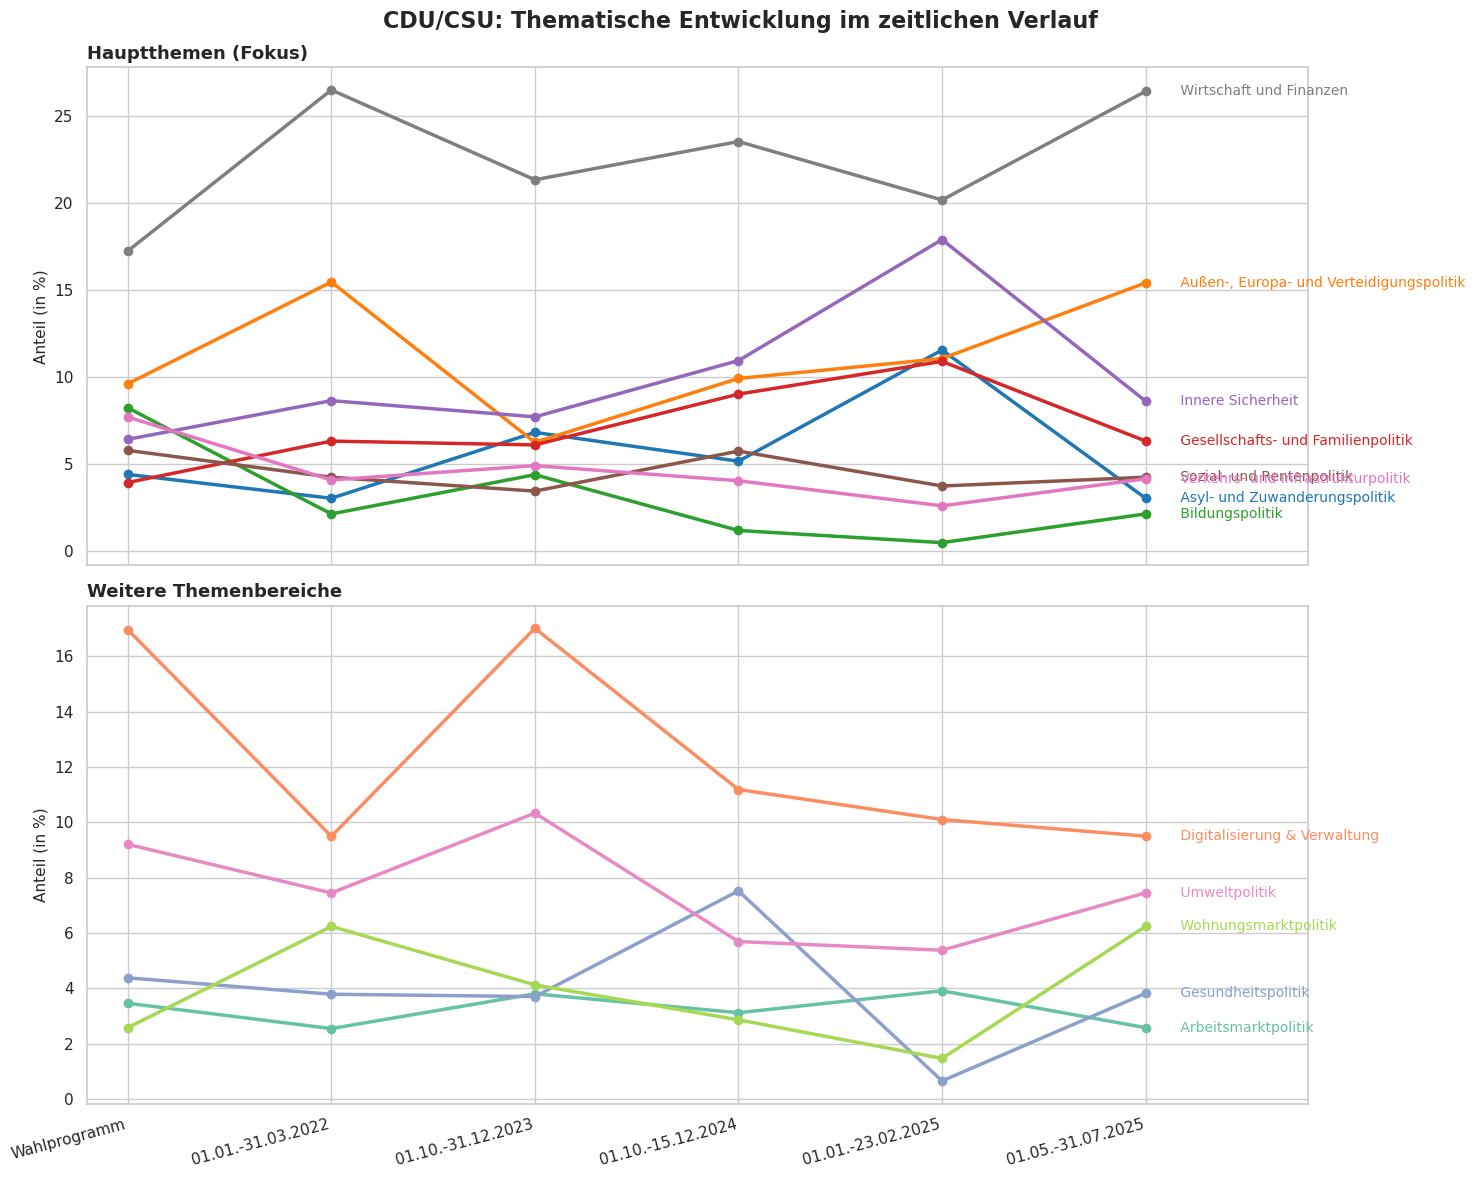

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-15.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('cdu_themen_verlauf_hard_500.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
cdu_data = cdu_data
cdu_data

,partei,zeitraum_name,topic,anteil
0,CDU/CSU,01.01.-23.02.2025,Arbeitsmarktpolitik,3.908795
1,CDU/CSU,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,11.563518
2,CDU/CSU,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",11.074919
3,CDU/CSU,01.01.-23.02.2025,Bildungspolitik,0.488599
4,CDU/CSU,01.01.-23.02.2025,Digitalisierung & Verwaltung,10.097720
...,...,...,...,...
73,CDU/CSU,Wahlprogramm,Sozial- und Rentenpolitik,5.795231
74,CDU/CSU,Wahlprogramm,Umweltpolitik,9.200693
75,CDU/CSU,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,7.712820
76,CDU/CSU,Wahlprogramm,Wirtschaft und Finanzen,17.258306
